In [5]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import random
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from main.utils import data_manage_utils, train_utils

importlib.reload(train_utils)
importlib.reload(data_manage_utils)

loading_folder = "2024_06_17-0642"
loading_spec = "RF"

ROOT_PATH = os.path.abspath("../../../")
TRAIN_DATA_FOLDER = os.path.join(ROOT_PATH, "data/training/training_results/", loading_spec, loading_folder)

# Finding corresponding prep data folder
settings_path = os.path.join(TRAIN_DATA_FOLDER, "estimation_settings.json")
PREP_DATA_FOLDER = data_manage_utils.find_data_path_by_settings_file(settings_path,ROOT_PATH)

In [6]:
pert_result_df_path = os.path.join(TRAIN_DATA_FOLDER,"pert_out_df.pkl.gz")

pert_df = pd.read_pickle(pert_result_df_path, compression="gzip")

pert_cols = list(set(pert_df.columns) - {"ARR_MIN_OF_DAY_COS", "ARR_MIN_OF_DAY_SIN", "ARR_DAY_SIN", "ARR_DAY_COS"})
USE_TH = False
if USE_TH:
    pert_cols = ["TEMP(C)","WIND_SPEED(KMH)","REL_HUMIDITY(PERCENT)","WIND_DRCT(DEG)", "SEA_LEVEL_PRESSURE(MILLIBAR)"]

pert_df

,DEP_DELAY(MINS),CRS_ELAPSED_TIME(MINS),NR_PREV_ARR_FLIGHTS(1HR),ARR_DAY_SIN,ARR_DAY_COS,ARR_MIN_OF_DAY_SIN,ARR_MIN_OF_DAY_COS,APPROACH_SPEED(KMH),TAIL_HEIGHT(M),PARKING_AREA(SQM),...,EVENT_HZ,EVENT_IC,EVENT_RA,EVENT_SN,EVENT_TS,RUNWAY_ERROR(PERC),y_true,pert_id,level,y
0,77.0,51.0,64.0,0.974928,-0.222521,-0.831470,-0.555570,259.280,6.324600,560.293571,...,0,0,0,0,0,1.00,2,DEP_DELAY(MINS)<6386798>,1,2
1,62.0,51.0,64.0,0.974928,-0.222521,-0.831470,-0.555570,259.280,6.324600,560.293571,...,0,0,0,0,0,1.00,2,DEP_DELAY(MINS)<6386798>,1,2
2,66.0,51.0,64.0,0.974928,-0.222521,-0.831470,-0.555570,259.280,6.324600,560.293571,...,0,0,0,0,0,1.00,2,DEP_DELAY(MINS)<6386798>,1,2
3,70.0,51.0,64.0,0.974928,-0.222521,-0.831470,-0.555570,259.280,6.324600,560.293571,...,0,0,0,0,0,1.00,2,DEP_DELAY(MINS)<6386798>,1,2
4,73.0,51.0,64.0,0.974928,-0.222521,-0.831470,-0.555570,259.280,6.324600,560.293571,...,0,0,0,0,0,1.00,2,DEP_DELAY(MINS)<6386798>,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10501874,2.0,69.0,96.0,0.433884,-0.900969,0.594823,-0.803857,255.576,9.000744,1525.176514,...,0,0,0,0,0,0.78,0,RUNWAY_ERROR(PERC)<6600848>,3,1
10501875,2.0,69.0,96.0,0.433884,-0.900969,0.594823,-0.803857,255.576,9.000744,1525.176514,...,0,0,0,0,0,0.82,0,RUNWAY_ERROR(PERC)<6600848>,3,1
10501876,2.0,69.0,96.0,0.433884,-0.900969,0.594823,-0.803857,255.576,9.000744,1525.176514,...,0,0,0,0,0,0.85,0,RUNWAY_ERROR(PERC)<6600848>,3,1
10501877,2.0,69.0,96.0,0.433884,-0.900969,0.594823,-0.803857,255.576,9.000744,1525.176514,...,0,0,0,0,0,0.88,0,RUNWAY_ERROR(PERC)<6600848>,3,1


In [7]:
pert_view_rf = pd.read_pickle("../pert_view_rf.pkl")
pert_view_adab = pd.read_pickle("../pert_view_adab.pkl")
pert_view_xgb = pd.read_pickle("../pert_view_xgb.pkl")

In [19]:
pert_view_xgb

,y_true,level,y,column,val,idx,pert_alarm,class_error
pert_id,,,,,,,,
1HOUR_PRECIPITATION(INCH)<10007538>,0,3,1,1HOUR_PRECIPITATION(INCH),0.075,10007538,True,True
1HOUR_PRECIPITATION(INCH)<10007606>,0,3,1,1HOUR_PRECIPITATION(INCH),0.055,10007606,True,True
1HOUR_PRECIPITATION(INCH)<10007615>,1,3,2,1HOUR_PRECIPITATION(INCH),0.010,10007615,True,True
1HOUR_PRECIPITATION(INCH)<10008480>,0,3,1,1HOUR_PRECIPITATION(INCH),0.075,10008480,True,True
1HOUR_PRECIPITATION(INCH)<10008715>,1,3,1,1HOUR_PRECIPITATION(INCH),0.010,10008715,True,False
...,...,...,...,...,...,...,...,...
WIND_SPEED(KMH)<9980742>,0,3,1,WIND_SPEED(KMH),13.890,9980742,True,True
WIND_SPEED(KMH)<9988026>,1,3,0,WIND_SPEED(KMH),16.668,9988026,True,True
WIND_SPEED(KMH)<9992635>,1,3,0,WIND_SPEED(KMH),14.816,9992635,True,True


In [8]:
pert_view_all = pert_view_rf.copy(deep=True)
pert_view_rf = pert_view_rf[pert_view_rf["pert_alarm"] == True]
pert_view_adab = pert_view_adab[pert_view_adab["pert_alarm"] == True]
pert_view_xgb = pert_view_xgb[pert_view_xgb["pert_alarm"] == True]

In [9]:
pert_view_rf = pert_view_rf[pert_view_rf["level"] >= 2]
pert_view_adab = pert_view_adab[pert_view_adab["level"] >= 2]
pert_view_xgb = pert_view_xgb[pert_view_xgb["level"] >= 2]

In [10]:
def plot_pert_graph(col):
    fig, axes = plt.subplots(2,2, figsize=(12,5))
    plt.subplots_adjust(hspace = 0.5)
    bins = np.histogram_bin_edges(pert_view_all[pert_view_all["column"] == col]["val"], bins='auto')
    all_data = pert_view_all[pert_view_all["column"] == col]
    ax = sns.histplot(data = all_data, x = "val", hue="y_true", multiple="stack", ax=axes[0][0], bins=bins, palette = ["C1", "C0", "k"])
    axes[0][0].set_title(f"Histogram of Test-Data n={len(all_data)}")
    ax.set(xlabel=col)
    rf_data = pert_view_rf[pert_view_rf["column"] == col]
    ax = sns.histplot(data = rf_data, x = "val", multiple="stack", ax=axes[0][1], bins = bins)
    axes[0][1].set_title(f"Histogram of Perturbation Alarms (RF) n={len(rf_data)}")
    ax.set(xlabel=col)
    adab_data = pert_view_adab[pert_view_adab["column"] == col]
    ax = sns.histplot(data = adab_data, x = "val", multiple="stack", ax=axes[1][0], bins = bins)
    axes[1][0].set_title(f"Histogram of Perturbation Alarms (ADAB) n={len(adab_data)}")
    ax.set(xlabel=col)
    xgb_data = pert_view_xgb[pert_view_xgb["column"] == col]
    ax = sns.histplot(data = xgb_data, x = "val", multiple="stack", ax=axes[1][1], bins = bins)
    axes[1][1].set_title(f"Histogram of Perturbation Alarms (XGB) n={len(xgb_data)}")
    ax.set(xlabel=col)

C:\Users\chrig\anaconda3\envs\ma-env39\lib\site-packages\seaborn\distributions.py:269: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  baselines.iloc[:, cols] = (curves


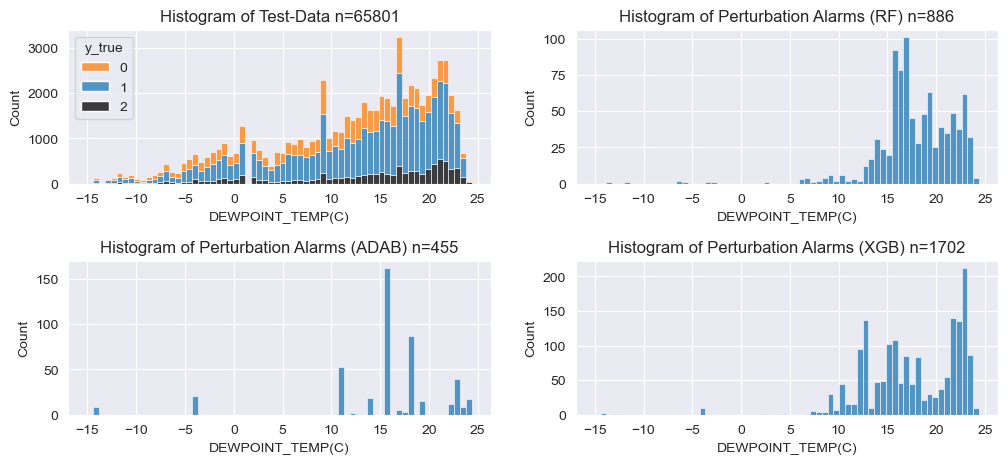

In [11]:
plot_pert_graph("DEWPOINT_TEMP(C)")

C:\Users\chrig\anaconda3\envs\ma-env39\lib\site-packages\seaborn\distributions.py:269: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  baselines.iloc[:, cols] = (curves


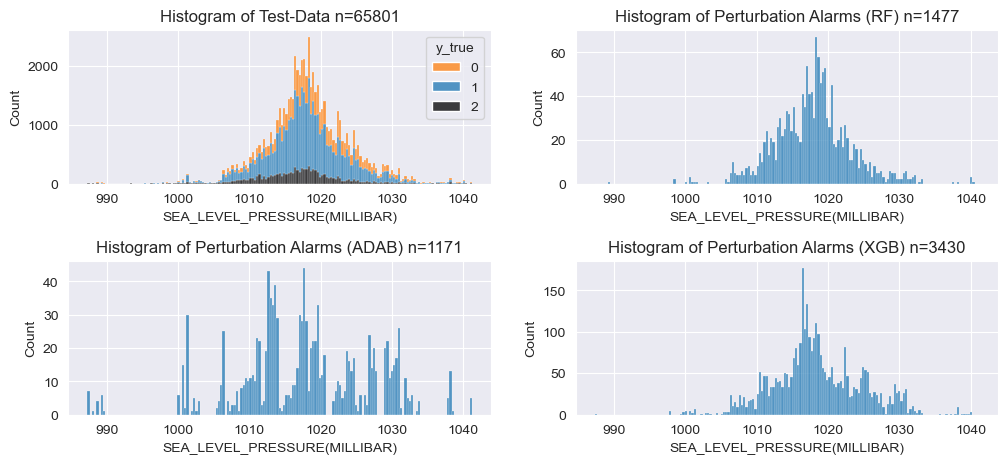

In [12]:
plot_pert_graph("SEA_LEVEL_PRESSURE(MILLIBAR)")

C:\Users\chrig\anaconda3\envs\ma-env39\lib\site-packages\seaborn\distributions.py:269: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  baselines.iloc[:, cols] = (curves


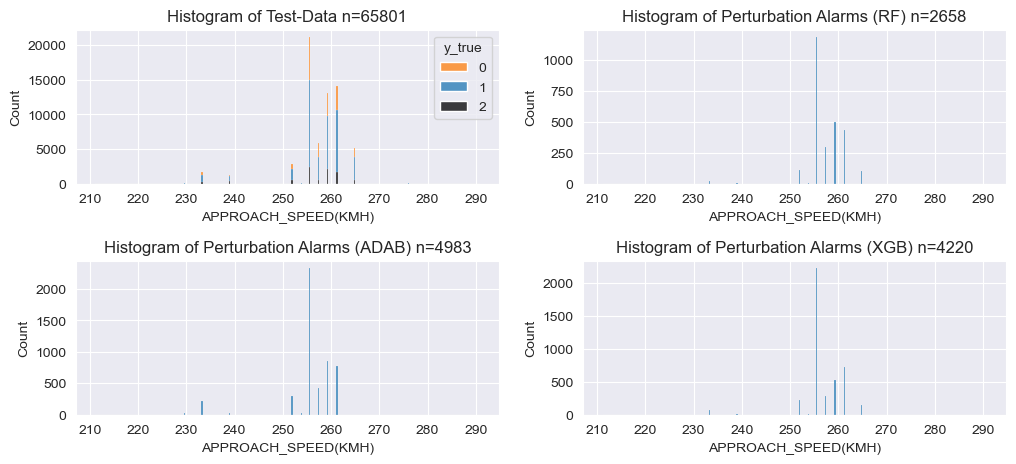

In [13]:
plot_pert_graph("APPROACH_SPEED(KMH)")

C:\Users\chrig\anaconda3\envs\ma-env39\lib\site-packages\seaborn\distributions.py:269: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  baselines.iloc[:, cols] = (curves


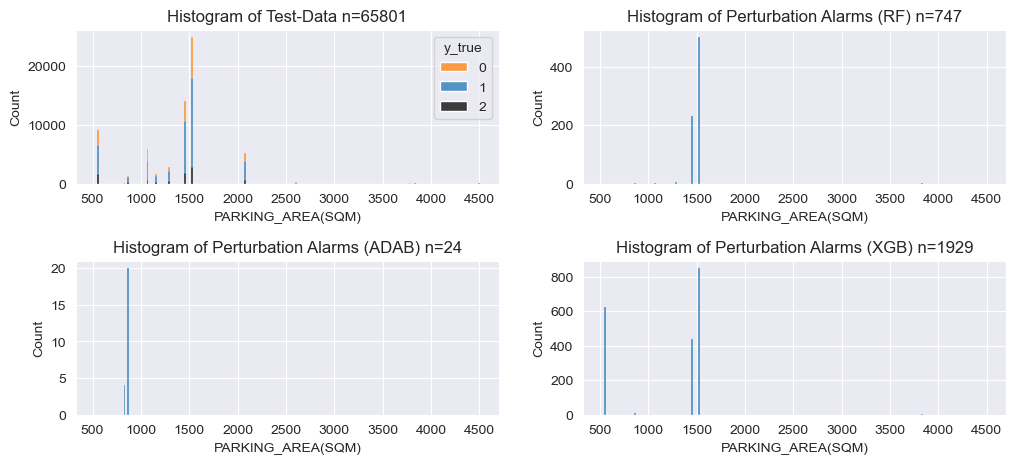

In [14]:
plot_pert_graph("PARKING_AREA(SQM)")

C:\Users\chrig\anaconda3\envs\ma-env39\lib\site-packages\seaborn\distributions.py:269: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  baselines.iloc[:, cols] = (curves


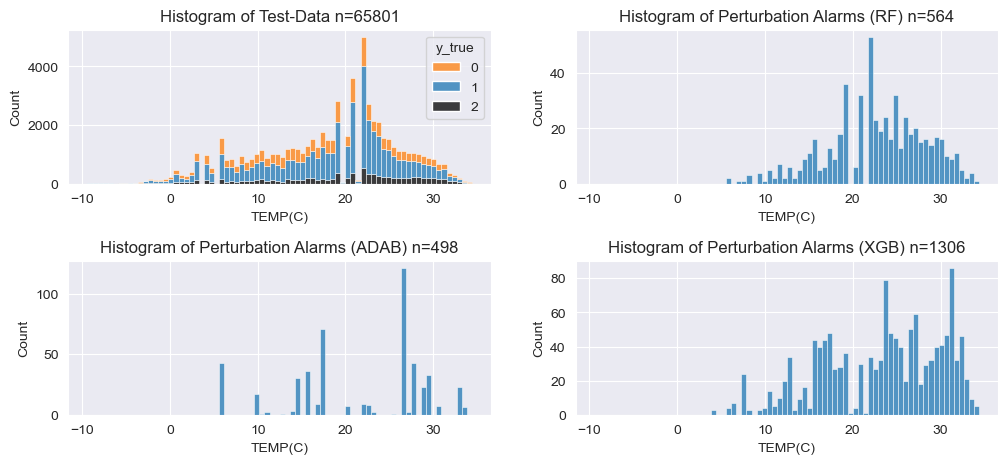

In [15]:
plot_pert_graph("TEMP(C)")

C:\Users\chrig\anaconda3\envs\ma-env39\lib\site-packages\seaborn\distributions.py:269: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  baselines.iloc[:, cols] = (curves


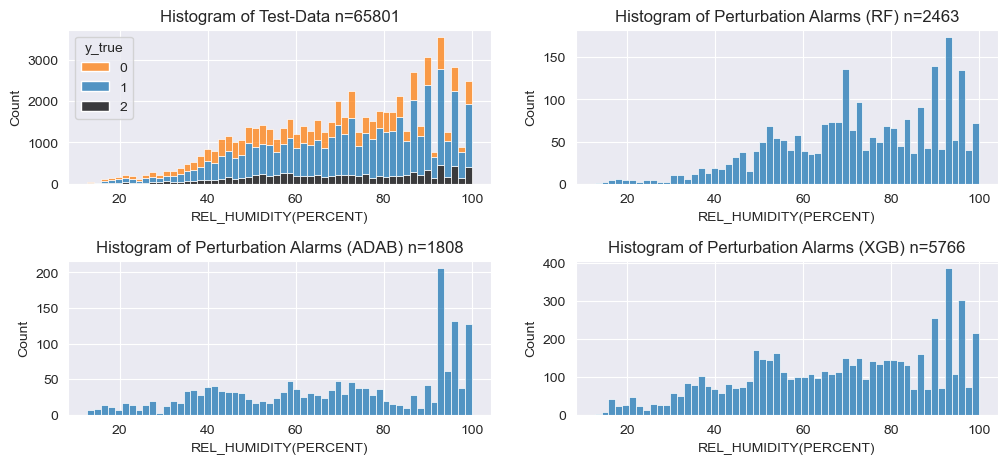

In [16]:
plot_pert_graph("REL_HUMIDITY(PERCENT)")

In [17]:
pert_view_rf

,y_true,level,y,column,val,idx,pert_alarm,class_error
pert_id,,,,,,,,
1HOUR_PRECIPITATION(INCH)<10026093>,1,3,0,1HOUR_PRECIPITATION(INCH),0.000,10026093,True,True
1HOUR_PRECIPITATION(INCH)<10042426>,0,3,0,1HOUR_PRECIPITATION(INCH),0.000,10042426,True,False
1HOUR_PRECIPITATION(INCH)<10042665>,1,3,0,1HOUR_PRECIPITATION(INCH),0.000,10042665,True,True
1HOUR_PRECIPITATION(INCH)<10055239>,1,3,0,1HOUR_PRECIPITATION(INCH),0.000,10055239,True,True
1HOUR_PRECIPITATION(INCH)<10055441>,0,3,0,1HOUR_PRECIPITATION(INCH),0.000,10055441,True,False
...,...,...,...,...,...,...,...,...
WIND_SPEED(KMH)<9981281>,1,3,1,WIND_SPEED(KMH),9.260,9981281,True,False
WIND_SPEED(KMH)<9983451>,1,3,1,WIND_SPEED(KMH),14.816,9983451,True,False
WIND_SPEED(KMH)<9985126>,1,3,0,WIND_SPEED(KMH),13.890,9985126,True,True


In [18]:
from main.utils import data_manage_utils

data_manage_utils.print_measures(pert_view_rf["y"], pert_view_rf["y_true"], ["0", "1", "2"])

--------------------
Global measures
Number of entries: 17442
Accuracy: 0.49409
Precision-µ: 0.49409
Recall-µ: 0.49409
F1-Score-µ: 0.49409
=
Precision-M: 0.51259
Recall-M: 0.54124
F1-Score-M: 0.49902


{'acc': 0.4940947139089554}